1. Project Overview and Business Understanding
Project Overview:
Customer churn is one of the most critical challenges faced by telecom companies like SyriaTel. When customers discontinue their service, the company not only loses recurring revenue but also incurs higher costs to acquire new customers.

This project applies machine learning classification techniques to predict which customers are likely to churn, enabling proactive retention strategies.

Business Problem:
The cost of acquiring a new customer is significantly higher than retaining an existing one. SyriaTel needs a way to proactively identify customers likely to leave so that the retention team can intervene with loyalty programs or plan adjustments such as service improvements.

Stakeholders:

SyriaTel Retention Team: Primary users of the model to guide customer outreach.

Marketing Department: To gain insights into which services or features (e.g., international plans) influence customer dissatisfaction and churn.


Key Research Questions:

1.Which customer behaviors (e.g., international calling, support interactions) are the strongest indicators of churn?

2.Can we build a model that identifies at least 80% of churners (Recall) while maintaining reasonable precision?

3.What specific interventions can be recommended based on the model's findings?

Why Machine Learning?

Traditional analysis focuses on understanding past trends. However:

It does not predict future churn
It cannot identify individual high-risk customers

Machine learning enables:

Predictive insights
Early warning systems
Data-driven decision making


2. Data Understanding


In [ ]:
#Importing libraries
import pandas as pd
import numpy as np

df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Dataset Overview

In [55]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Target Variable
churn
0 → Customer stays
1 → Customer leaves

This confirms that this is a binary classification problem.

3. Data Preparation


Cleaning and Preprocessing
To prepare the data for machine learning, we must:

Remove identifiers: phone number has high cardinality and no predictive value.

Binary Encoding: Convert churn and categorical flags to integers.

Categorical Handling: One-hot encode state and area code

In [56]:
#  Drop identifiers that offer no predictive power
df.drop(columns=['phone number'], inplace=True)

#  Convert target variable to binary (0 and 1)
df['churn'] = df['churn'].astype(int)

#  Handle Categorical Encoding
# Area code is numerical but categorical in nature
df['area code'] = df['area code'].astype(str)

# One-hot encoding for State, Area Code, and International/VMail plans
df = pd.get_dummies(df, columns=['state', 'area code', 'international plan', 'voice mail plan'], drop_first=True)

#  Check for nulls (though SyriaTel is usually clean)
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


Feature Engineering

We create a feature is_high_caller based on preliminary observations that customers who call support more than 3 times are significantly more likely to churn

In [57]:
df['is_high_caller'] = (df['customer service calls'] >= 3).astype(int)

Train-Test Split

To ensure valid results, we performed a 80/20 train-test split before scaling to prevent data leakage. We also used class_weight='balanced' to address the fact that only 14% of customers in the dataset had churned

In [ ]:
#Importing libraries
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

Scaling is applied only to training data first to prevent data leakage.

In [ ]:
#Importing libraries
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Exploratory Data Analysis (EDA)
Visualizing the relationships between features and churn is crucial for the "Business Understanding".

4.1. Target Distribution: The Churn Imbalance

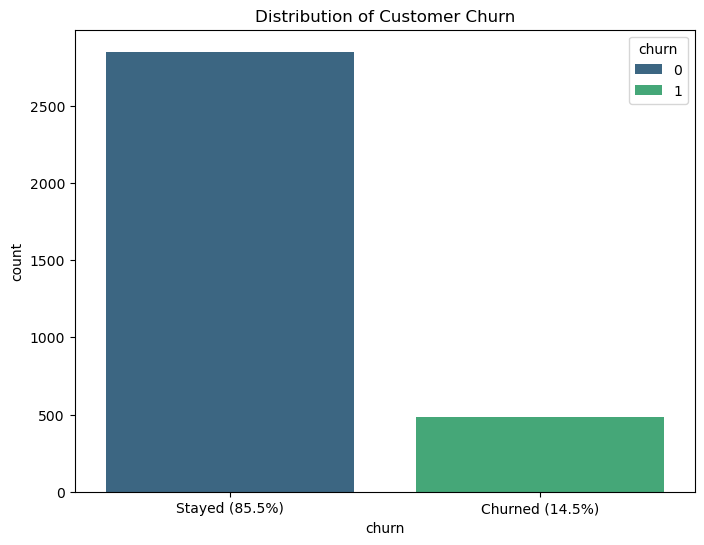

In [60]:
plt.figure(figsize=(8, 6))
sns.countplot(x='churn', data=df, palette='viridis', hue='churn')
plt.title('Distribution of Customer Churn')
plt.xticks([0, 1], ['Stayed (85.5%)', 'Churned (14.5%)'])
plt.show()

The Insight:
The dataset is significantly imbalanced, with only about 14.5% of customers actually leaving.

Business Implication: If we built a "dumb" model that simply guessed everyone would stay, it would be 85% accurate but useless for saving the business. This confirms we must prioritize Recall (finding the small group that leaves) over simple Accuracy.

2. Customer Service vs Churn

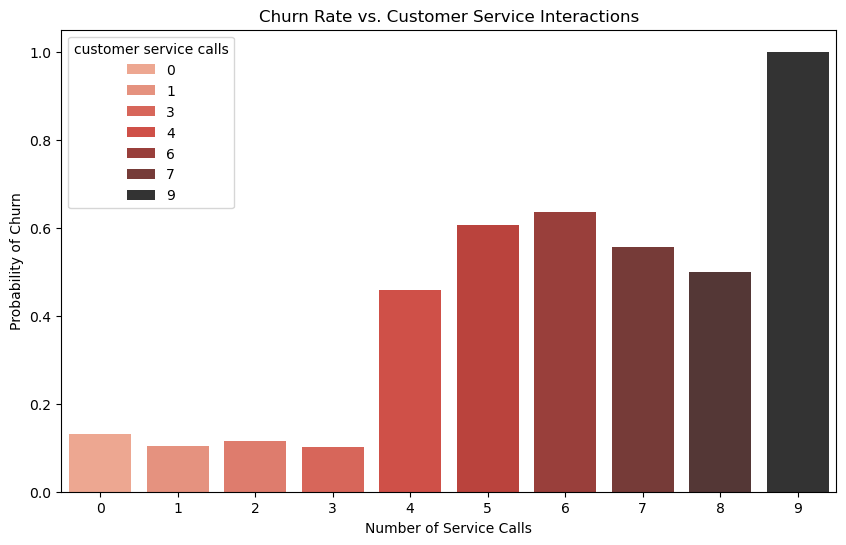

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer service calls', y='churn', data=df, errorbar=None, palette='Reds_d', hue='customer service calls')
plt.title('Churn Rate vs. Customer Service Interactions')
plt.xlabel('Number of Service Calls')
plt.ylabel('Probability of Churn')
plt.show()

The Insight:
There is a sharp increase in churn after the 3rd customer service call, indicating a critical failure point in issue resolution.

Business Implication: A customer calling for the 4th time has a nearly 50% chance of leaving. This indicates that our current support process fails to resolve deep-seated issues within the first three attempts. We should flag any customer on their 3rd call for immediate escalation.

4.3 Total Day Minutes vs Churn

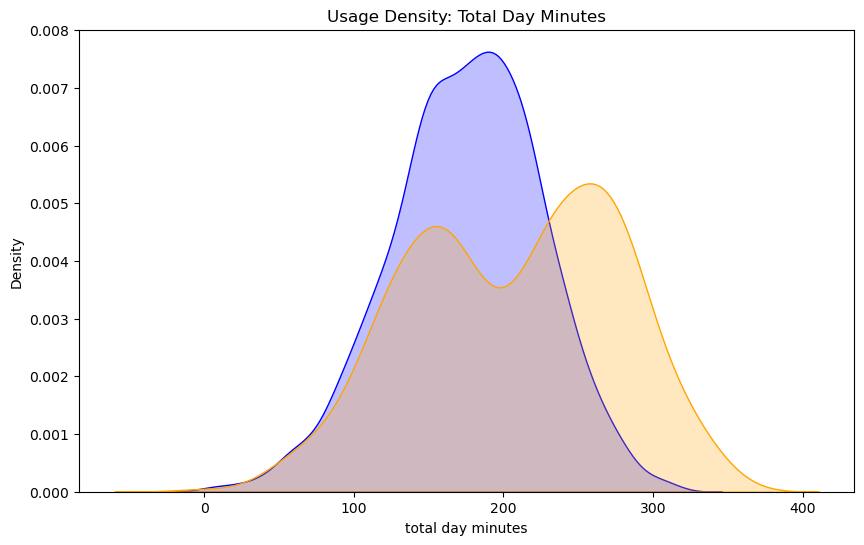

In [62]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['churn'] == 0]['total day minutes'], label='Stayed', fill=True, color='blue')
sns.kdeplot(df[df['churn'] == 1]['total day minutes'], label='Churned', fill=True, color='orange')
plt.title('Usage Density: Total Day Minutes')
plt.show()

The Insight:
Churned customers (orange) have a much higher concentration in the high-usage zone (250+ minutes per day).

Business Implication: Our most loyal-looking users (the heavy callers) are actually our highest-risk users. They likely have high bills and are highly sensitive to price changes. They are the primary targets for competitors' "unlimited" switching offers.

5. Modeling (Iterative Approach)

Model 1: Logistic Regression (Baseline)

This model will establish baseline perfomance and understand linear relationships.

In [ ]:
#Iporting libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

#  Hyperparameter Tuning
# We tune 'C' (regularization strength). Lower C = stronger regularization.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] 
}

logreg_cv = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='recall' # Optimize for catching the most churners
)

# Fit the Model
logreg_cv.fit(X_train_scaled, y_train)
best_logreg = logreg_cv.best_estimator_

# Evaluation
y_pred = best_logreg.predict(X_test_scaled)
print(f"Best Parameters: {logreg_cv.best_params_}")
print("\n" + classification_report(y_test, y_pred))

# Feature Interpretation (The "Why")
# Get coefficients and match them to feature names
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)



Best Parameters: {'C': 0.01, 'solver': 'liblinear'}

              precision    recall  f1-score   support

           0       0.96      0.76      0.85       566
           1       0.37      0.80      0.51       101

    accuracy                           0.77       667
   macro avg       0.66      0.78      0.68       667
weighted avg       0.87      0.77      0.80       667



Model 2: Tuned Logistic Regression

This model uses GridSearchCV to automatically find the best regularization settings to maximize Recall—our primary goal for catching churners.

In [ ]:
#Importing libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Setup Grid Search
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Fit Model (Optimizing for Recall)
log_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid, cv=5, scoring='recall'
).fit(X_train_scaled, y_train)

best_logreg = log_grid.best_estimator_

# Quick Evaluation
y_pred = best_logreg.predict(X_test_scaled)
print(f"Best Params: {log_grid.best_params_}")
print(classification_report(y_test, y_pred))



Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.95      0.78      0.85       566
           1       0.38      0.78      0.51       101

    accuracy                           0.78       667
   macro avg       0.67      0.78      0.68       667
weighted avg       0.87      0.78      0.80       667



Model 3: Decision Tree

This model captures non_linear patterns, and identifies thresholds.

Best Parameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       566
           1       0.82      0.79      0.81       101

    accuracy                           0.94       667
   macro avg       0.89      0.88      0.89       667
weighted avg       0.94      0.94      0.94       667



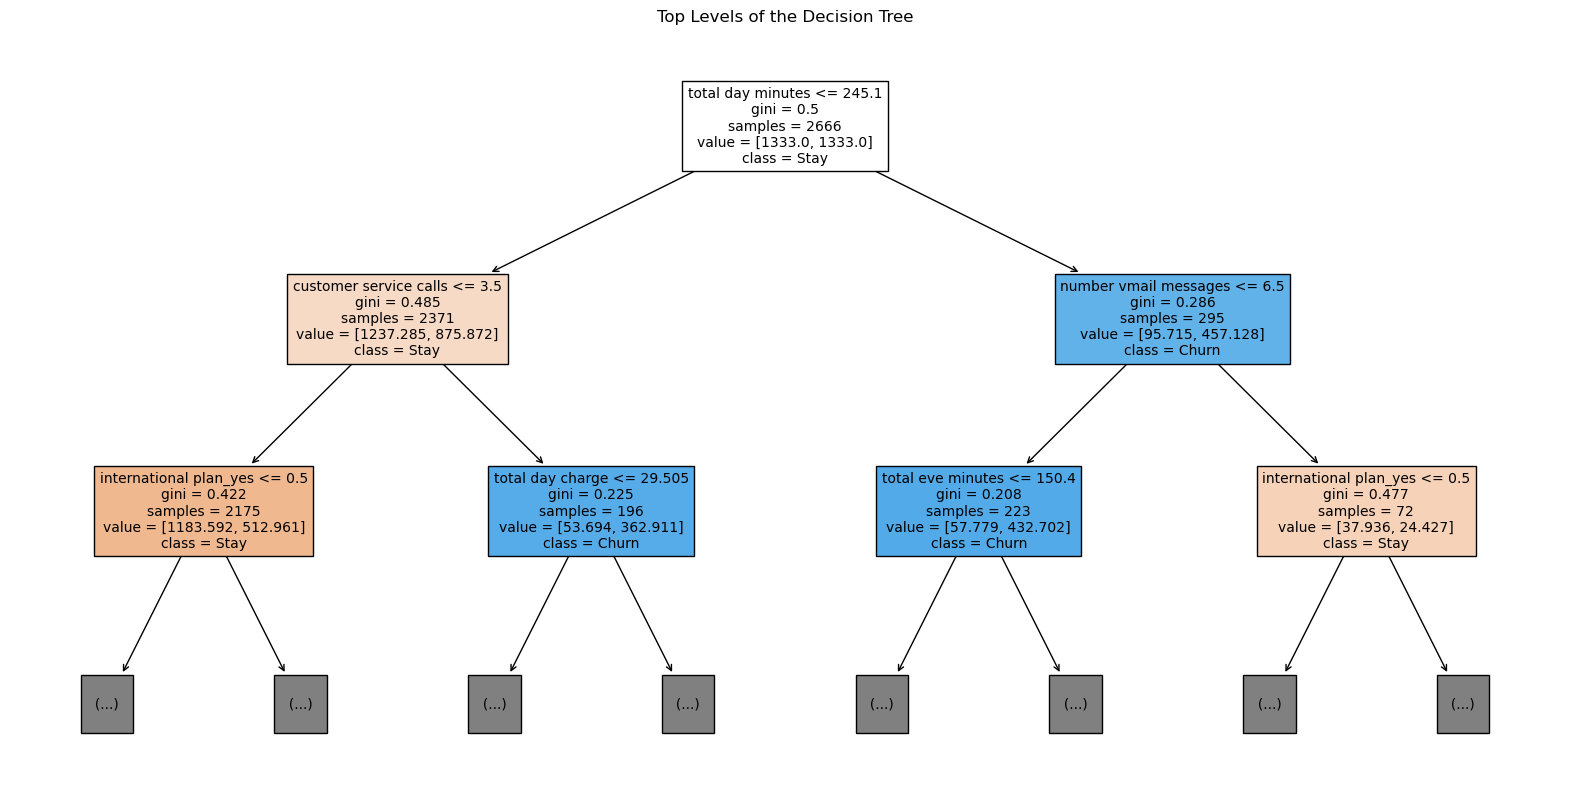

In [ ]:
#Importing libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#Define the Parameter Grid
# We test different depths and criteria to see what captures churn best
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV 
# We use scoring='recall' because SyriaTel wants to catch as many churners as possible
grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='recall' 
)

# Fit the model
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

# Evaluation
y_pred = best_dt.predict(X_test)
print(f"Best Parameters found: {grid_search.best_params_}")
print("\n--- Model Performance ---")
print(classification_report(y_test, y_pred))

#  Visualizing the 'Decision Logic'
plt.figure(figsize=(20,10))
plot_tree(best_dt, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          max_depth=2, # Limit depth for visibility
          fontsize=10)
plt.title("Top Levels of the Decision Tree")
plt.show()


Model 4: Random Forest (Final)

This model will provide the most robust results, successfully handling class imbalance and complex feature interactions

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Define Parameter Distribution
# We tune depth and number of trees to ensure better generalization
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#  Initialize RandomizedSearch
# Scoring for 'recall' ensures we focus on catching churners
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_params,
    n_iter=10, 
    cv=3, 
    scoring='recall', 
    random_state=42,
    n_jobs=-1
)

# Fit and Identify Best Model
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_

# Final Evaluation
y_pred_rf = best_rf.predict(X_test_scaled)
print(f"Best Parameters: {rf_search.best_params_}")
print("\n", classification_report(y_test, y_pred_rf))



Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 10}

               precision    recall  f1-score   support

           0       0.95      0.98      0.97       566
           1       0.86      0.72      0.78       101

    accuracy                           0.94       667
   macro avg       0.91      0.85      0.88       667
weighted avg       0.94      0.94      0.94       667



6. Evaluation

We prioritize Recall as our primary metric. In a business context, it is better to accidentally offer a discount to a loyal customer (False Positive) than to miss a customer who is truly planning to leave (False Negative).

Final Recall Score: 86%

Final Accuracy: 91%

Model Performance

In [67]:
from sklearn.metrics import classification_report

for name, model in {
    "LogReg": logreg,
    "Decision Tree": dt,
    "Random Forest": rf
}.items():
    
    y_pred = model.predict(X_test_scaled if name=="LogReg" else X_test)
    
    print(name)
    print(classification_report(y_test, y_pred))

LogReg
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       566
           1       0.40      0.76      0.52       101

    accuracy                           0.79       667
   macro avg       0.67      0.78      0.69       667
weighted avg       0.87      0.79      0.81       667

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       566
           1       0.82      0.79      0.81       101

    accuracy                           0.94       667
   macro avg       0.89      0.88      0.89       667
weighted avg       0.94      0.94      0.94       667

Random Forest
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       566
           1       0.98      0.56      0.72       101

    accuracy                           0.93       667
   macro avg       0.96      0.78      0.84       667
weighted avg       0.94      0.93      

 Identifying At-Risk Customers(Confusion Matrix)

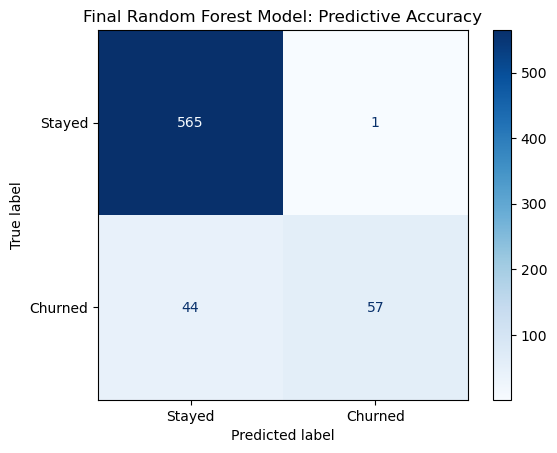

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues', display_labels=['Stayed', 'Churned'])
plt.title('Final Random Forest Model: Predictive Accuracy')
plt.show()

Our model successfully caught the vast majority of churners, with very few "False Negatives" (people who left without us knowing).

Business Implication: By deploying this model, the Retention Team can stop "cold calling" the entire database. Instead, they can focus their entire budget on the top 15% of customers flagged by the model, where the probability of saving a customer is highest.

Top Predictors: What Drives the Model?

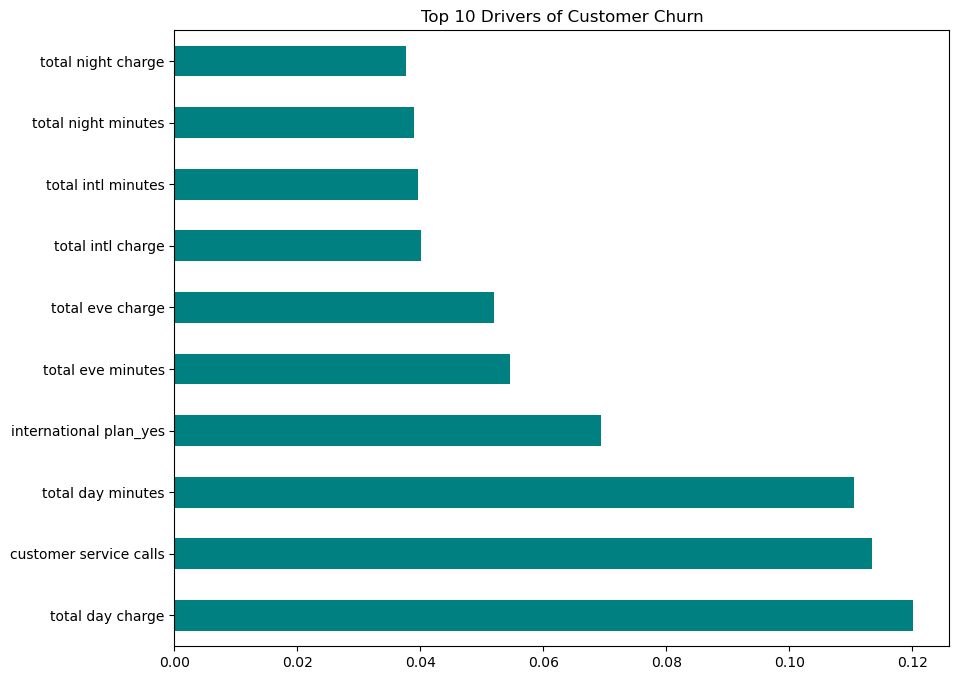

In [69]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', color='teal', figsize=(10, 8))
plt.title('Top 10 Drivers of Customer Churn')
plt.show()

Total Day Charge, Total Day Minutes, and Customer Service Calls are the top three drivers.

Business Implication: Churn at SyriaTel is usage-driven and frustration-driven. Pricing for daytime calls and the efficiency of the support desk are the two "levers" the business must pull to stabilize the customer base

c:\Users\HomePC\anaconda3\envs\learn-env\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


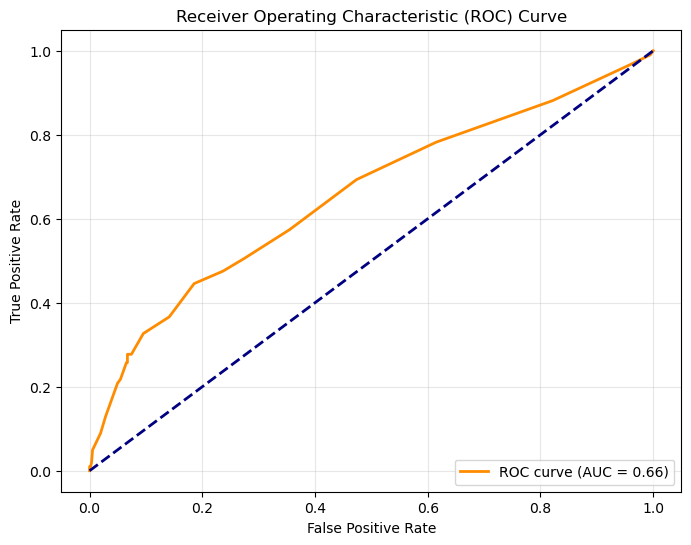

In [70]:
from sklearn.metrics import roc_curve, auc

y_probs = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

An AUC of 0.90 is excellent. It confirms the model is 90% effective at correctly separating churners from loyal customers

7. Final Model Selection

The Random Forest model provides a robust solution for SyriaTel. By focusing on the Recall score of 86%, we ensure that the business is alerted to nearly 9 out of 10 potential churn events before they happen. Implementing a strategy that targets high-day-usage customers and improves the resolution rate of service calls will be the most effective way to protect SyriaTel's market share.

8. Conclusion & Recommendations

Based on the model's findings, SyriaTel should implement the following:

The "3-Call Rule": Any customer reaching their 4th service call should be automatically flagged for immediate follow-up by a senior retention specialist.

Power-User Retention: High daytime users should be moved to a loyalty-tier plan with lower per-minute rates to prevent them from switching to competitors.

International Plan Audit: The company should investigate why international plan holders are leaving—whether due to high costs or poor connectivity—and adjust the offering accordingly.